<a href="https://colab.research.google.com/github/chiraswykj/Machine_learning_2_lab/blob/main/ML2_Exp_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("student_data.csv")
print(df.head())

   Student_ID    Name  Age  Gender  ...  Attendance  Assignments  Exam_Score  Result
0           1   Aarav   19    Male  ...          92          8.0          85    Pass
1           2    Diya   20  Female  ...          95          9.0          91    Pass
2           3   Rohan   18    Male  ...          78          6.0          68    Pass
3           4  Ananya   19  Female  ...          88          8.0          82    Pass
4           5  Vikram   21    Male  ...          75          7.0          70    Pass

[5 rows x 9 columns]


In [ ]:
df.columns = df.columns.str.strip()
print(df.head())
print(df.info())
print(df.isnull().sum())

   Student_ID    Name  Age  Gender  ...  Attendance  Assignments  Exam_Score  Result
0           1   Aarav   19    Male  ...          92          8.0          85    Pass
1           2    Diya   20  Female  ...          95          9.0          91    Pass
2           3   Rohan   18    Male  ...          78          6.0          68    Pass
3           4  Ananya   19  Female  ...          88          8.0          82    Pass
4           5  Vikram   21    Male  ...          75          7.0          70    Pass

[5 rows x 9 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Student_ID   10 non-null     int64  
 1   Name         10 non-null     object 
 2   Age          10 non-null     int64  
 3   Gender       10 non-null     object 
 4   Study_Hours  9 non-null      float64
 5   Attendance   10 non-null     int64  
 6   Assignments  9 non-null   

In [ ]:

df.fillna(df.mean(numeric_only=True),inplace=True)


In [ ]:
print(df.isnull().sum())

Student_ID     0
Name           0
Age            0
Gender         0
Study_Hours    0
Attendance     0
Assignments    0
Exam_Score     0
Result         0
dtype: int64


In [ ]:
x=df[["Age","Study_Hours","Assignments","Exam_Score"]]
y=df[["Result"]]

encoder=LabelEncoder()
y=encoder.fit_transform(y)
print(y)

[0 0 0 0 0 0 0 0 0 0]


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
print("Training samples:",len(x_train))
print("Testing samples:",len(x_test))
model=DecisionTreeClassifier(random_state=42)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print("Actual:",y_test)
print("Predicted:",y_pred)

Training samples: 8
Testing samples: 2
Actual: [0 0]
Predicted: [0 0]


In [ ]:
precision= precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
accuracy=accuracy_score(y_test,y_pred)
print("precision:",precision)
print("recall:",recall)
print("f1:",f1)
print("accuracy:",accuracy)

precision: 0.0
recall: 0.0
f1: 0.0
accuracy: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[2]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


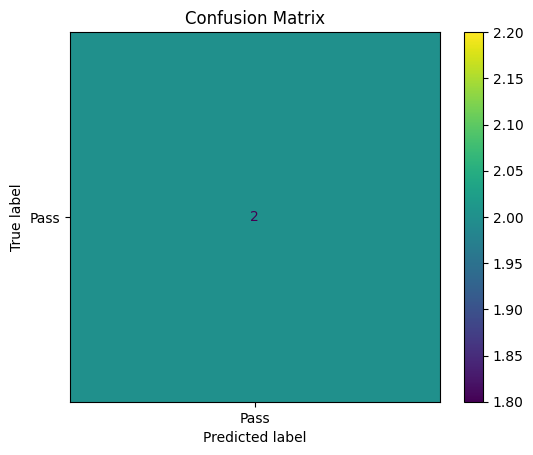

In [ ]:
disp=ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)
disp.plot()
plt.title("Confusion Matrix")
plt.show()